# 项目2：重庆GDP全国排位变化分析（2011-2025）

- 数据来源：国家统计局《分省年度数据》（data/分省年度数据.xlsx）
- 指标：地区生产总值（亿元），2011-2025年，31个省级行政区
- 配套脚本：trend_analysis.py 一条龙跑完清洗、分析、出图；本 Notebook 为图文版，按步骤拆分并附踩坑记录

In [1]:
import re
import sys
import textwrap
from pathlib import Path

import pandas as pd
import matplotlib

# 无人值守脚本用无界面后端，交付物是图片文件而非弹窗
# matplotlib.use("Agg")  # Notebook 内联显示，无需无界面后端
from matplotlib import pyplot as plt

# 中文显示：Windows 自带黑体为主、微软雅黑兜底
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
# 数学负号(U+2212)在黑体里没有字形，关掉后用普通连字符，否则负数刻度变方框
plt.rcParams["axes.unicode_minus"] = False




## Step 1 数据预览：先看清结构再动手

不设表头先看原始结构，确认真正表头在第4行（header=3）。

坑清单：
1. 时间列混入16行季度数据
2. 地区名带空格/下划线等特殊字符（如“辽 宁”）
3. GDP列有 `...` 和 `—` 占位符，isna() 看不见
4. 地区列有 `-` 等脏值，尾部还有3行脚注

In [2]:
# 第一步：先不设表头读入数据，看原始结构（前几行和后几行可能不是需要的数据）
file_path = Path.cwd() / "data" / "分省年度数据.xlsx"
row = pd.read_excel(file_path, engine="calamine")
print("===== 原始数据 =====")
df_shape = row.shape
print(f"整体形状（行，列）：{df_shape}")
print("\n前10行原样：\n")
print(row.head(10))
print("\n后10行原样：\n")
print(row.tail(10))

# 第二步：扫描时间列的口径构成--年行和季行各有多少(header=3)
df = pd.read_excel(file_path, engine="calamine", header=3)

rows_year = df["时间"].astype(str).str.strip().str.endswith("年").sum()
rows_quarter = df["时间"].astype(str).str.strip().str.contains("季度").sum()
print("===== 时间口径构成 =====")
print(f"总行数：{df.shape[0]}, 以年结尾{rows_year}行，以季度结尾{rows_quarter}行")
print(df["时间"].head(5))
print(df["时间"].tail(5))

# 第三步：扫描数值列里的占位符--isna 看不到的数据在唯一值里
print("\n===== 各列唯一值抽样(找缺失值，占位符，异常值) =====")
anomaly_value = []
for col in df.columns:
    non_numeric_cols = []
    values = df[col].unique()
    for value in values:
        if not re.search(r"省|市|\d+年|[\d+\.\d+]", str(value)):
            non_numeric_cols.append(value)
    line = f"[{col}]异常值内容：{non_numeric_cols}(共{len(non_numeric_cols)}种)"
    anomaly_value.append(line)
    # print(line)


report = "\n".join(
    [
        "============================== Step 1: 数据预览 ===============================",
        "=" * 30 + " 原始数据 " + "=" * 30,
        f"\n整体形状（行，列）：{df_shape}",
        f"前10行原样：\n{row.head(10)}",
        f"后10行原样：\n{row.tail(10)}",
        "=" * 30 + " 时间口径构成 " + "=" * 30,
        f"\n总行数：{df.shape[0]}, 以年结尾{rows_year}行，以季度结尾{rows_quarter}行",
        f"前5行时间：\n{df['时间'].head(5)}",
        f"后5行时间：\n{df['时间'].tail(5)}",
        "=" * 30 + " 异常值 " + "=" * 30,
        "\n".join(anomaly_value),
        "=" * 79,
        "\n\n",
    ]
)
# print(report)



===== 原始数据 =====
整体形状（行，列）：(493, 3)

前10行原样：

       数据库：分省年度数据 Unnamed: 1  Unnamed: 2
0  指标：地区生产总值 (亿元)        NaN         NaN
1  时间：2011年-2025年        NaN         NaN
2              地区         时间  地区生产总值(亿元)
3             北京市      2025年     52073.4
4             北京市      2024年     49670.2
5             北京市      2023年     47353.7
6             北京市      2022年     45222.4
7             北京市      2021年     44350.7
8             北京市      2020年     38503.6
9             北京市      2019年       37767

后10行原样：

                                            数据库：分省年度数据 Unnamed: 1 Unnamed: 2
483                                        新疆维吾尔_自 治 区      2017年    11460.8
484                                        新疆维吾尔_自 治 区      2016年     9913.9
485                                        新疆维吾尔_自 治 区      2015年     9545.7
486                                        新疆维吾尔_自 治 区      2014年     9400.2
487                                        新疆维吾尔_自 治 区      2013年     8518.4
488                            

## Step 2 数据清洗：每删一行都留痕

踩坑记录：
1. 去重曾用 `duplicated(keep=False)` 把重复对整体删除，造成账目缺口；改为 `keep="first"` 并打印明细人工核对
2. 地区名正则 `[\s+-_]` 里 `-` 夹在中间会被解释为字符范围，必须挪到类尾 `[\s+_-]`
3. 占位符先 `to_numeric(errors="coerce")` 转成 NaN 再去重，让空值行在去重时可见，同一（地区,年份）保留有值的那行
4. 2011年宁夏、海南、西藏、青海4省缺失，用各省2012-2013年均值插补，并在 `数据来源` 列标记“填充数据”

In [3]:

total_rows = df.shape[0]
# print(df)
# 时间列处理
# 筛选行：去除季度和脏行
year_na_mask = df["时间"].astype(str).str.strip().str.endswith("年")
year_na_detail = df[~year_na_mask]
rows_drop_year = year_na_detail.shape[0]
print(f"时间列异常值处理：共去除{rows_drop_year}行异常值（季度行和脏值）")
year_na_detail_str = (
    year_na_detail.to_string(index=False) if not year_na_detail.empty else "无"
)
print(f"异常值明细：\n{year_na_detail_str}")

# 将时间列转换为数值类型
df = df[year_na_mask]
df["时间"] = pd.to_numeric(df["时间"].str.replace("年", "")).astype("int64")

# 地区列处理
# 筛选行：去除地区异常值
area_na_mask = df["地区"].str.contains(r"省\s*$|市\s*$|区\s*$")
area_na_detail = df[~area_na_mask]
rows_drop_area = area_na_detail.shape[0]
area_na_detail_str = (
    area_na_detail.to_string(index=False) if not area_na_detail.empty else "无"
)
print(f"地区列异常值处理：删除{rows_drop_area}行异常值（非省、市、区）")
print(f"异常值明细：\n{textwrap.indent(area_na_detail_str, '    ')}")

# 格式化地区列，先处理空白字符和下划线等特殊字符，再删除省、市等后缀
df["地区"] = (
    df["地区"]
    .astype(str)
    .str.strip()
    .str.replace(r"[\s+_-]", "", regex=True)
    .str.replace(r"省|市|维吾尔自治区|壮族自治区|回族自治区|自治区", "", regex=True)
)
df = df[area_na_mask]
# print(df)

# 按时间地区去重
df["地区生产总值(亿元)"] = pd.to_numeric(
    df["地区生产总值(亿元)"], errors="coerce"
).astype("float64")
df = df.sort_values("地区生产总值(亿元)", na_position="last")
dup_mask = df.duplicated(subset=["时间", "地区"], keep="first")
dup_detail = df[df.duplicated(subset=["时间", "地区"], keep=False)].sort_values(
    ["地区", "时间"]
)
df = df[~dup_mask].sort_values(["地区", "时间"])
count_drop_dup = dup_mask.sum()
print(f"按时间地区去重：共去除{count_drop_dup}行重复值")
dup_detail_str = dup_detail.to_string(index=False) if not dup_detail.empty else "无"
print(f"重复行明细(保留第一个值)：\n{dup_detail_str}")

# 生产总值异常值处理
# print(df)

gdp_na_mask = df["地区生产总值(亿元)"].isna()

# 用相邻年份值填充缺失值
# 取每个地区前两年的均值
first2_mean = (
    df[~gdp_na_mask]
    .sort_values(["地区", "时间"])
    .groupby("地区")
    .head(2)
    .groupby("地区")["地区生产总值(亿元)"]
    .mean()
)

# 拼接填充明细
fill_map = pd.DataFrame(
    {
        "地区": df.loc[gdp_na_mask, "地区"],
        "时间": df.loc[gdp_na_mask, "时间"],
        "填充值": df.loc[gdp_na_mask, "地区"].map(first2_mean),
    }
).reset_index(drop=True)

if fill_map["填充值"].isna().any():
    sys.exit(
        f"以下地区无GDP数据，无法填充，请确认\n{fill_map[fill_map['填充值'].isna()]}"
    )
fill_detail = fill_map[["地区", "时间", "填充值"]].to_string(index=False)
print(
    f"地区生产总值缺失值处理：共{fill_map.shape[0]}条缺失数据，使用各地区前两年均值填充"
)
print(f"填充明细：\n{fill_detail}")

# 填充数据
df.loc[gdp_na_mask, "地区生产总值(亿元)"] = fill_map["填充值"].to_numpy()
df["数据来源"] = "原始数据"
df.loc[gdp_na_mask, "数据来源"] = "填充数据"
print(
    f"数据填充后 GDP 列缺失值 {df['地区生产总值(亿元)'].isna().sum()} 个, （预期0个）"
)


area_after_clean = df["地区"].unique().tolist()
print(f"清洗后地区数：{len(area_after_clean)}个，（预期31个）")
print(f"地区清单：{area_after_clean}")

rows_after_clean = df.shape[0]
rows_expected = rows_after_clean + rows_drop_year + count_drop_dup + rows_drop_area
if total_rows != rows_expected or rows_after_clean != 31 * 15:
    sys.exit("数据清洗后，行数与预期不一致，检查数据是否完整")

report += "\n".join(
    [
        "=============================== Step 2: 数据清洗 ===============================",
        "数据总览：",
        f"总行数：{total_rows}",
        f"清洗后行数：{rows_after_clean}",
        "数据处理明细：",
        f"  时间列异常值处理：共去除{rows_drop_year}行异常值（季度行和脏值）",
        f"  异常值明细：\n{textwrap.indent(year_na_detail_str, '    ')}",
        f"  地区列异常值处理：删除{rows_drop_area}行异常值（非省、市、区）",
        f"  异常值明细：\n{textwrap.indent(area_na_detail_str, '    ')}",
        f"  按时间地区去重：共去除{count_drop_dup}行重复值",
        f"  重复行明细：\n{textwrap.indent(dup_detail_str, '    ')}",
        f"  地区生产总值缺失值处理：共{fill_map.shape[0]}条缺失数据，使用各地区前两年均值填充",
        f"  填充明细：\n{textwrap.indent(fill_detail, '    ')}",
        f"  数据填充后 GDP 列缺失值 {df['地区生产总值(亿元)'].isna().sum()} 个, （预期0个）",
        f"  清洗后地区数：{len(area_after_clean)}个,（预期31个）",
        f"  地区清单：{area_after_clean}",
        "自洽校验：",
        f"  清洗数据 + 清洗后数据：{rows_after_clean} + {rows_drop_year} + {count_drop_dup} + {rows_drop_area} = {total_rows} ✓",
        f"  清洗后行数：{rows_after_clean} = 31 * 15 = {31 * 15} ✓",
        "=" * 79,
        "\n\n",
    ]
)

output_path = Path.cwd() / "cleaned_data.xlsx"
output_path.parent.mkdir(parents=True, exist_ok=True)
with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    df.to_excel(writer, index=False)




时间列异常值处理：共去除21行异常值（季度行和脏值）
异常值明细：
                                                                  地区        时间 地区生产总值(亿元)
                                                                 辽宁省 2024年第4季度     9373.6
                                                                 辽宁省 2024年第3季度     8239.4
                                                                 辽宁省 2024年第2季度     7779.5
                                                                 辽宁省 2024年第1季度     7148.3
                                                                 辽宁省       NaN    20381.5
                                                                 吉林省       。。。    13942.7
                                                                浙江省  2024年第4季度    26012.5
                                                                浙江省  2024年第3季度    22250.7
                                                                浙江省  2024年第2季度    21787.1
                                                                浙江

## Step 3 探索分析：让数字自己讲故事

- 分析一：全国总量趋势（口径：2011年含4条插补值）
- 分析二：重庆排位用 `groupby("时间").rank()` 在年份内横向比较，method="min" 使并列名次取较小值
- 分析三：增速差值pp = 重庆增速 - 全国增速
- 分析四：只筛“反直觉候选”不下结论——增速跑赢全国但排位下降的年份（2019）是主角

In [4]:

# 分析一：2011~2025年全国GDP总值（亿元）趋势
total_gdp = df.groupby("时间")["地区生产总值(亿元)"].sum()
total_gdp_str = total_gdp.to_string(float_format="{:.1f}".format)
print("\n===== 全国GDP总值（亿元），2011年含4条填充值 =====")
print(total_gdp_str)

# 分析二：重庆每年全国排位；rank在年份内横向比较，method=min使并列名次取较小值
# 重庆每年全国排位
df["排位"] = (
    df.groupby("时间")["地区生产总值(亿元)"]
    .rank(ascending=False, method="min")
    .astype("Int64")
)
cq_rank = df[df["地区"] == "重庆"][["时间", "地区生产总值(亿元)", "排位"]].sort_values(
    "时间"
)
print("\n===== 重庆历年GDP与全国排位 =====")
cq_rank_str = cq_rank.to_string(index=False)
print(cq_rank_str)
print(
    f"起点(2011)排位：{cq_rank.iloc[0]['排位']}，终点({cq_rank.iloc[-1]['时间']})排位：{cq_rank.iloc[-1]['排位']}"
)

# 分析三：重庆同比增速 Vs 全国同比增速
cq_growth = cq_rank.set_index("时间")["地区生产总值(亿元)"].pct_change() * 100
total_growth = total_gdp.pct_change() * 100
growth_compare = pd.DataFrame({"重庆增速%": cq_growth, "全国增速%": total_growth})
growth_compare["差值pp"] = growth_compare["重庆增速%"] - growth_compare["全国增速%"]
print("\n===== 同比增速对比（百分点差=重庆-全国） =====")
growth_compare_str = growth_compare.to_string(float_format="{:.2f}".format)
print(growth_compare_str)

# 分析四：反直觉发现候选--不预设结论，只筛除值得展开的年份
# （1）增速高于全国，但排位却下降的年份；（2）单年排位跳动最大的年份

seep_up_rank_down = growth_compare.index[
    (growth_compare["差值pp"] > 0) & (cq_rank.set_index("时间")["排位"].diff() > 0)
]
print(f"增速高于全国，但排位却下降的年份：{seep_up_rank_down.tolist() or '无'}")
rank_2019 = {df[df["时间"] == 2019]["排位"].values[0]}
print(f"2019年排位明细：{rank_2019}")

rank_shift = cq_rank.set_index("时间")["排位"].diff()
big_shift_years = rank_shift[rank_shift.abs() >= 1]
big_shift_years_str = big_shift_years.to_string(index=True)
print_info = big_shift_years_str if big_shift_years.size > 0 else "无"
print(f"重庆单年排位变动明细(正=下降，负=上升)：\n{print_info}")

report += "\n".join(
    [
        "=============================== Step 3: 探索分析 ===============================",
        "\n分析一：2011~2025年全国GDP总值（亿元）趋势",
        textwrap.indent(total_gdp_str, "  "),
        "\n分析二：重庆每年全国排位",
        textwrap.indent(cq_rank_str, "  "),
        f"起点(2011)排位：{cq_rank.iloc[0]['排位']}，终点({cq_rank.iloc[-1]['时间']})排位：{cq_rank.iloc[-1]['排位']}",
        "\n分析三：重庆同比增速 Vs 全国同比增速",
        textwrap.indent(growth_compare_str, "  "),
        "\n分析四：反直觉发现候选,（1）增速高于全国，但排位却下降的年份；（2）单年排位跳动最大的年份",
        "\n  增速高于全国，但排位却下降的年份：",
        textwrap.indent(
            f"增速高于全国，但排位却下降的年份：{seep_up_rank_down.tolist() or '无'}",
            "    ",
        ),
        "\n  2019年排位明细：",
        textwrap.indent(f"2019年排位明细：{rank_2019}", "    "),
        "\n  重庆单年排位变动明细(正=下降，负=上升)：",
        textwrap.indent(print_info, "    "),
        "\n\n",
    ]
)

# 结论段：关键数字全部引用上方计算结果，避免手写错数；叙述部分为固定文案
rank_start = int(cq_rank.iloc[0]["排位"])
rank_end = int(cq_rank.iloc[-1]["排位"])
gdp_start = total_gdp.iloc[0] / 10000
gdp_end = total_gdp.iloc[-1] / 10000
cq_start = cq_rank.iloc[0]["地区生产总值(亿元)"] / 10000
cq_end = cq_rank.iloc[-1]["地区生产总值(亿元)"] / 10000
cq_2019 = growth_compare.loc[2019, "重庆增速%"]
nat_2019 = growth_compare.loc[2019, "全国增速%"]
conclusion = (
    f"重庆GDP全国排位15年观察：从第{rank_start}位到第{rank_end}位\n"
    f"2011至2025年，全国GDP总量从{gdp_start:.2f}万亿元增至{gdp_end:.2f}万亿元（约{gdp_end / gdp_start:.1f}倍）；"
    f"重庆从{cq_start:.2f}万亿元增至{cq_end:.2f}万亿元（约{cq_end / cq_start:.1f}倍），跑赢大盘，"
    f"全国排位从第{rank_start}位升至第{rank_end}位。\n"
    "但上升不是匀速的。2012-2016年是重庆的黄金五年，增速连续五年跑赢全国2个百分点以上，排位从19爬到17；"
    "随后进入僵持，2014-2018年连续五年钉死在第17位。真正的转折藏在2019年："
    f"这一年重庆增速{cq_2019:.2f}%，仍高于全国的{nat_2019:.2f}%，排位却从17降到18——"
    "跑赢了平均分，却输给了邻居，因为排位是存量竞争，看的是与前后名次的相对差距，不是与均值的差距。"
    "2023年重庆夺回第17位，2025年进一步升至第16位，创十五年新高。\n"
    "数据说明：2011年宁夏、海南、西藏、青海4省份数据缺失，采用各省2012-2013年均值插补；"
    "全国总量及增速已包含插补值的影响。"
)
report += "\n".join(
    [
        "=================================== 结论 ===================================",
        conclusion,
        "=" * 79,
    ]
)

print(report)
# 数据预览保存到 docs 目录作为交付物；utf-8-sig 保证 Windows 记事本打开不乱码
report_path = Path.cwd() / "docs" / "report.txt"
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(report, encoding="utf-8-sig")




===== 全国GDP总值（亿元），2011年含4条填充值 =====
时间
2011    499865.1
2012    551419.7
2013    607950.8
2014    659599.8
2015    704746.0
2016    764462.7
2017    845179.8
2018    930356.2
2019   1001773.7
2020   1031101.6
2021   1166800.6
2022   1222892.0
2023   1283801.5
2024   1337605.8
2025   1393768.5

===== 重庆历年GDP与全国排位 =====
  时间  地区生产总值(亿元)  排位
2011     10314.1  19
2012     11797.8  18
2013     13275.8  17
2014     14911.7  17
2015     16305.9  17
2016     18271.1  17
2017     20260.8  17
2018     21866.8  17
2019     23689.6  18
2020     25158.1  18
2021     28092.5  17
2022     28771.8  18
2023     30614.3  17
2024     32046.7  17
2025     33757.9  16
起点(2011)排位：19.0，终点(2025.0)排位：16.0

===== 同比增速对比（百分点差=重庆-全国） =====
      重庆增速%  全国增速%  差值pp
时间                      
2011    NaN    NaN   NaN
2012  14.39  10.31  4.07
2013  12.53  10.25  2.28
2014  12.32   8.50  3.83
2015   9.35   6.84  2.51
2016  12.05   8.47  3.58
2017  10.89  10.56  0.33
2018   7.93  10.08 -2.15
2019   8.34   7.68  0.66
20

7185

## Step 4 可视化：四张图讲一条故事线

- 图01 全国趋势：数值换算万亿元，2011年标注插补口径
- 图02 重庆排位：`invert_yaxis()` 让“向上=进步”，y轴聚焦15-20
- 图03 增速差值：全项目唯一的高亮色留给主角年份2019
- 图04 排位热力图：31省x15年全景，行按2025年排位排序，重庆红框高亮

踩坑记录：
1. `savefig` 必须写在 `show` 之前——show 会关闭画布，之后再存图得到空图
2. SimHei 缺数学负号(U+2212)字形，需 `axes.unicode_minus=False`，否则负数刻度变方框

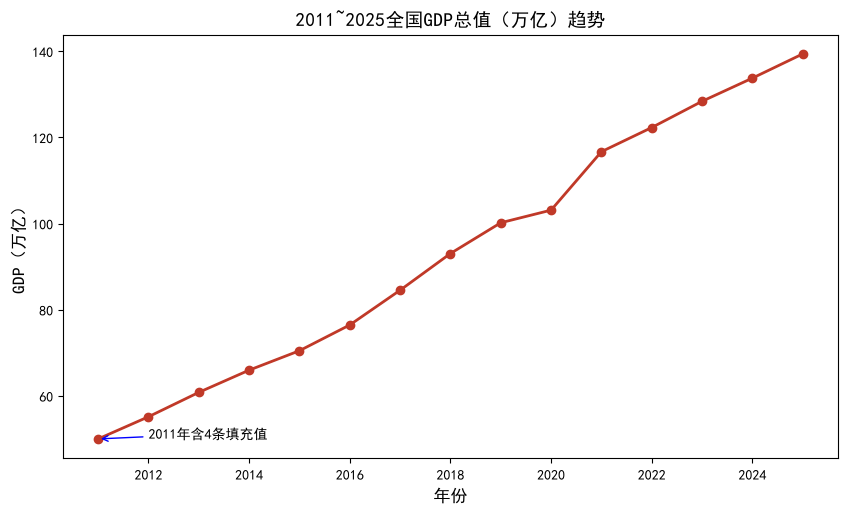

已保存图表 01_全国GDP总值趋势.png


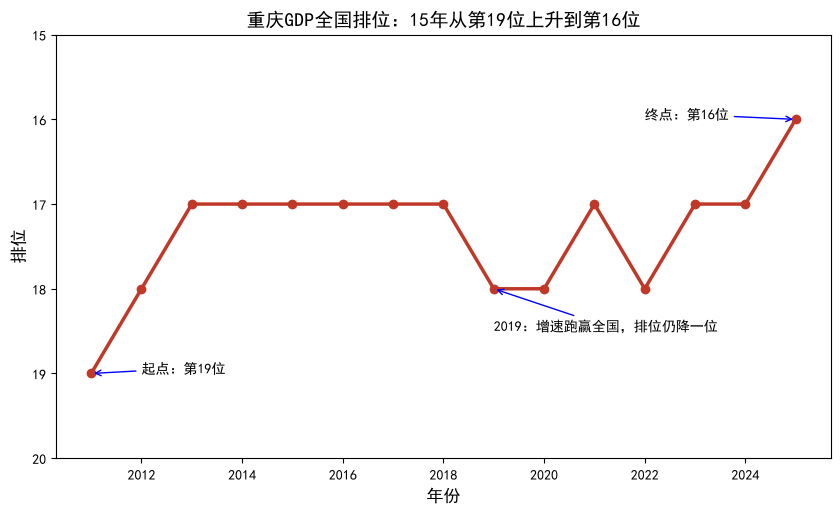

已保存图表 02_重庆每年全国排位.png


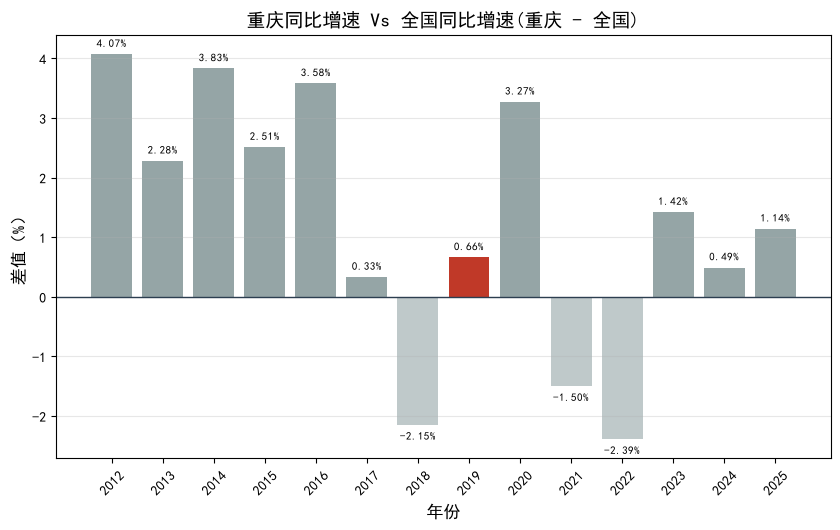

已保存图表 03_增速差值对比.png


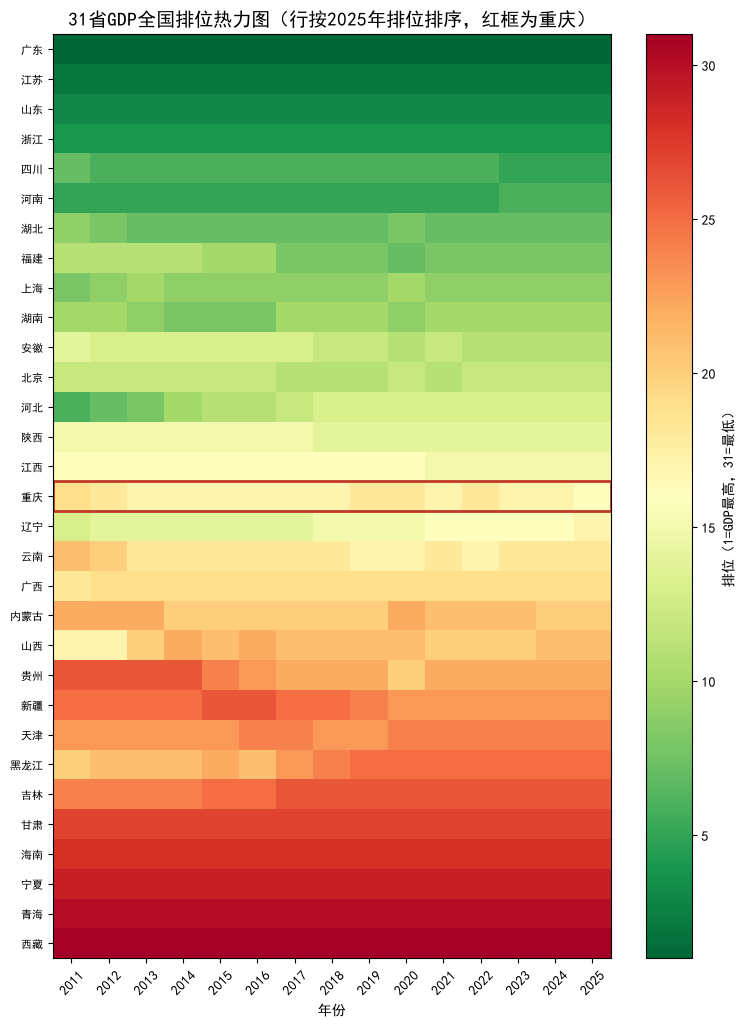

已保存图表 04_31省排位热力图.png


In [5]:
charts_path = Path.cwd() / "charts"
charts_path.mkdir(parents=True, exist_ok=True)

cq_color = "#c03928"
bg_color = "#2c3e50"


def save_fig(fig, name):
    fig.savefig(charts_path / name, dpi=150, bbox_inches="tight")
    plt.show()  # Notebook 内联预览
    plt.close(fig)
    print(f"已保存图表 {name}")


# 图01:2011~2025全国GDP总值趋势
total_trillion = (total_gdp / 10000).round(2)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(total_trillion.index, total_trillion.values, color=cq_color, marker="o", lw=2)
ax.set_title("2011~2025全国GDP总值（万亿）趋势", fontsize=14)
ax.set_xlabel("年份", fontsize=12)
ax.set_ylabel("GDP（万亿）", fontsize=12)
ax.annotate(
    "2011年含4条填充值",
    xy=(2011, total_trillion.iloc[0]),
    xytext=(2012, total_trillion.iloc[0]),
    arrowprops=dict(arrowstyle="->", color="blue"),
    fontsize=10,
)
save_fig(fig, "01_全国GDP总值趋势.png")

# 图02：重庆每年全国排位
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(cq_rank["时间"], cq_rank["排位"], color=cq_color, marker="o", lw=2.5, ms=6)
ax.invert_yaxis()  # 倒序显示排位，1排在最前面
ax.set_yticks(range(15, 21))
ax.set_title("重庆GDP全国排位：15年从第19位上升到第16位", fontsize=14)
ax.set_xlabel("年份", fontsize=12)
ax.set_ylabel("排位", fontsize=12)
ax.annotate(
    "起点：第19位",
    xy=(2011, 19),
    xytext=(2012, 19),
    arrowprops=dict(arrowstyle="->", color="blue"),
    fontsize=10,
)
ax.annotate(
    "终点：第16位",
    xy=(2025, 16),
    xytext=(2022, 16),
    arrowprops=dict(arrowstyle="->", color="blue"),
    fontsize=10,
)
ax.annotate(
    "2019：增速跑赢全国，排位仍降一位",
    xy=(2019, cq_rank[cq_rank["时间"] == 2019]["排位"].values[0]),
    xytext=(2019, cq_rank[cq_rank["时间"] == 2019]["排位"].values[0] + 0.5),
    arrowprops=dict(arrowstyle="->", color="blue"),
    fontsize=10,
)
save_fig(fig, "02_重庆每年全国排位.png")

# 图03： 重庆同比增速 Vs 全国同比增速
diff_pp = growth_compare["差值pp"].dropna().round(2)
colors = [
    cq_color if y == 2019 else ("#95A5A6" if v > 0 else "#BFC9CA")
    for y, v in diff_pp.items()
]
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(
    diff_pp.index,
    diff_pp.values,
    color=colors,
    width=0.8,
)
ax.axhline(0, color=bg_color, lw=1)
for y, v in diff_pp.items():
    ax.text(y, v + (0.12 if v > 0 else -0.25), f"{v:.2f}%", ha="center", fontsize=8)
ax.set_title("重庆同比增速 Vs 全国同比增速(重庆 - 全国)", fontsize=14)
ax.set_xlabel("年份", fontsize=12)
ax.set_ylabel("差值（%）", fontsize=12)
ax.set_xticks(diff_pp.index)
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=45)
save_fig(fig, "03_增速差值对比.png")

# 图04：31省排位热力图（进阶图）——行按2025年排位从高到低排，重庆行红框高亮
from matplotlib.patches import Rectangle

rank_pivot = df.pivot(index="地区", columns="时间", values="排位").astype(float)
rank_pivot = rank_pivot.sort_values(2025)  # 行按最新年份排位从1开始往下排
fig, ax = plt.subplots(figsize=(9, 12))
im = ax.imshow(rank_pivot.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(rank_pivot.columns)))
ax.set_xticklabels(rank_pivot.columns, rotation=45)
ax.set_yticks(range(len(rank_pivot.index)))
ax.set_yticklabels(rank_pivot.index, fontsize=8)
cq_row = rank_pivot.index.get_loc("重庆")
ax.add_patch(
    Rectangle(
        (-0.5, cq_row - 0.5),
        len(rank_pivot.columns),
        1,
        fill=False,
        edgecolor=cq_color,
        lw=2,
    )
)
ax.set_title("31省GDP全国排位热力图（行按2025年排位排序，红框为重庆）", fontsize=14)
ax.set_xlabel("年份")
fig.colorbar(im, ax=ax, label="排位（1=GDP最高，31=最低）")
save_fig(fig, "04_31省排位热力图.png")


## 结论（约300字）

> **重庆GDP全国排位15年观察：从第19位到第16位**
>
> 2011至2025年，全国GDP总量从49.99万亿元增至139.38万亿元（约2.8倍）；重庆从1.03万亿元增至3.38万亿元（约3.3倍），跑赢大盘，全国排位从第19位升至第16位。
>
> 但上升不是匀速的。2012-2016年是重庆的黄金五年，增速连续五年跑赢全国2个百分点以上，排位从19爬到17；随后进入僵持，2014-2018年连续五年钉死在第17位。真正的转折藏在2019年：这一年重庆增速8.34%，仍高于全国的7.68%，排位却从17降到18——跑赢了平均分，却输给了邻居，因为排位是存量竞争，看的是与前后名次的相对差距，不是与均值的差距。2023年重庆夺回第17位，2025年进一步升至第16位，创十五年新高。
>
> 数据说明：2011年宁夏、海南、西藏、青海4省份数据缺失，采用各省2012-2013年均值插补；全国总量及增速已包含插补值的影响。